# 01 — Exploration SQL et Data Quality

## Objectifs de ce notebook
1. Charger les 9 fichiers Olist dans une base DuckDB
2. Vérifier la qualité des données (doublons, nulls, cohérence)
3. Comprendre la structure relationnelle entre les tables
4. Analyser la distribution temporelle et la fréquence d'achat
5. Justifier la fenêtre de churn (180 jours) avec des données

## Pourquoi DuckDB ?
DuckDB permet d'exécuter du SQL analytique directement sur des CSV, sans serveur à installer.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style("whitegrid")

# Chemins
DATA_RAW = Path("../data/raw")

# Création connexion DuckDB persistante
con = duckdb.connect("../data/olist.duckdb")
print("Connexion DuckDB établie")

Connexion DuckDB établie


## 2. Chargement des fichiers CSV en tables SQL

On utilise `read_csv_auto` de DuckDB qui détecte automatiquement les types 
et le délimiteur. Le `CREATE OR REPLACE TABLE` permet de relancer la cellule 
sans erreur si on doit recharger les données.

### Ce qu'il faut surveiller en sortie
- Le nombre de lignes par table doit être cohérent avec la documentation 
  Kaggle d'Olist (~99k orders, ~99k customers, ~112k order_items).
- Si une table affiche 0 ligne, vérifier le nom du fichier dans `data/raw/`.

In [2]:
# Mapping fichiers
tables = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

for table_name, filename in tables.items():
    filepath = DATA_RAW / filename
    con.execute(f"""
        CREATE OR REPLACE TABLE {table_name} AS 
        SELECT * FROM read_csv_auto('{filepath}')
    """)
    count = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    print(f"{table_name}: {count:,} lignes")

customers: 99,441 lignes
geolocation: 1,000,163 lignes
order_items: 112,650 lignes
order_payments: 103,886 lignes
order_reviews: 99,224 lignes
orders: 99,441 lignes
products: 32,951 lignes
sellers: 3,095 lignes
category_translation: 71 lignes


## 3. Vue d'ensemble des volumétries

On consulte le catalogue système de DuckDB (`duckdb_tables()`) pour avoir 
une vue synthétique de toutes les tables et leur taille.

### Interprétation attendue
La table `geolocation` est généralement la plus volumineuse (~1M lignes) car 
elle contient un mapping zip code → coordonnées GPS. C'est normal et on ne 
l'utilisera que pour des features géographiques optionnelles.

In [3]:
# Vue d'ensemble des tables
overview = con.execute("""
    SELECT 
        table_name,
        estimated_size AS row_count
    FROM duckdb_tables()
    WHERE schema_name = 'main'
    ORDER BY estimated_size DESC
""").df()
print(overview)

             table_name  row_count
0           geolocation    1000163
1           order_items     112650
2        order_payments     103886
3             customers      99441
4                orders      99441
5         order_reviews      99224
6              products      32951
7               sellers       3095
8  category_translation         71


## 4. Inspection des schémas des tables centrales

On regarde la structure des 3 tables qu'on va le plus utiliser :
- **`orders`** : la table de faits (1 ligne = 1 commande)
- **`customers`** : la dimension client
- **`order_items`** : le détail des produits par commande

In [4]:
# Schéma de la table orders (table centrale)
print("ORDERS :")
print(con.execute("DESCRIBE orders").df())

print("\nCUSTOMERS :")
print(con.execute("DESCRIBE customers").df())

print("\nORDER_ITEMS :")
print(con.execute("DESCRIBE order_items").df())

ORDERS :
                     column_name column_type null   key default extra
0                       order_id     VARCHAR  YES  None    None  None
1                    customer_id     VARCHAR  YES  None    None  None
2                   order_status     VARCHAR  YES  None    None  None
3       order_purchase_timestamp   TIMESTAMP  YES  None    None  None
4              order_approved_at   TIMESTAMP  YES  None    None  None
5   order_delivered_carrier_date   TIMESTAMP  YES  None    None  None
6  order_delivered_customer_date   TIMESTAMP  YES  None    None  None
7  order_estimated_delivery_date   TIMESTAMP  YES  None    None  None

CUSTOMERS :
                column_name column_type null   key default extra
0               customer_id     VARCHAR  YES  None    None  None
1        customer_unique_id     VARCHAR  YES  None    None  None
2  customer_zip_code_prefix     VARCHAR  YES  None    None  None
3             customer_city     VARCHAR  YES  None    None  None
4            customer_s

## 5. Data Quality Checks

### Ce qu'on vérifie
- **Doublons** sur les clés primaires (customer_id, order_id)
- **Valeurs nulles** sur les champs critiques (date d'achat notamment)

### Interprétation attendue
- Pas de doublons sur `order_id` (clé primaire propre)
- Pas de doublons sur `customer_id` non plus, mais attention : `customer_id` 
  n'est PAS l'identifiant client persistant (voir cellule 6)
- Quelques timestamps nuls peuvent exister sur les commandes annulées

In [5]:
# Doublons sur les IDs critiques
quality_checks = con.execute("""
    SELECT 
        'customers - duplicate customer_id' AS check_name,
        COUNT(*) - COUNT(DISTINCT customer_id) AS issues
    FROM customers
    UNION ALL
    SELECT 
        'orders - duplicate order_id',
        COUNT(*) - COUNT(DISTINCT order_id)
    FROM orders
    UNION ALL
    SELECT 
        'orders - null customer_id',
        SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END)
    FROM orders
    UNION ALL
    SELECT 
        'orders - null purchase timestamp',
        SUM(CASE WHEN order_purchase_timestamp IS NULL THEN 1 ELSE 0 END)
    FROM orders
""").df()

print(quality_checks)

                          check_name  issues
0  customers - duplicate customer_id     0.0
1        orders - duplicate order_id     0.0
2          orders - null customer_id     0.0
3   orders - null purchase timestamp     0.0


## 6. Le piège : `customer_id` vs `customer_unique_id`

### Explication
Dans la table `customers` :
- **`customer_id`** : un identifiant **par commande**. Si un même client passe 
  3 commandes, il aura 3 `customer_id` différents !
- **`customer_unique_id`** : le **vrai identifiant persistant** du client.

### Conséquence pour le churn
Si on calcule la récence/fréquence avec `customer_id`, **chaque client 
apparaît comme un mono-acheteur** et le churn n'a aucun sens.

### Règle absolue
Pour toute analyse client (RFM, churn, segmentation), on **JOIN systématiquement** 
sur `customer_unique_id`.

In [6]:
# Olist a 2 identifiants clients différents !
investigation = con.execute("""
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(DISTINCT customer_id) AS distinct_customer_id,
        COUNT(DISTINCT customer_unique_id) AS distinct_customer_unique_id
    FROM customers
""").df()

print(investigation)
print("\n  customer_id = ID par commande (change à chaque achat)")
print("  customer_unique_id = vrai identifiant client persistant")
print(" Pour le churn, on utilise TOUJOURS customer_unique_id")

   total_rows  distinct_customer_id  distinct_customer_unique_id
0       99441                 99441                        96096

  customer_id = ID par commande (change à chaque achat)
  customer_unique_id = vrai identifiant client persistant
 Pour le churn, on utilise TOUJOURS customer_unique_id


## 7. Distribution temporelle des commandes

On visualise le volume mensuel de commandes pour :
1. Identifier la **période couverte** par le dataset (point de référence pour 
   définir la date d'observation du churn)
2. Détecter d'éventuelles **anomalies** (mois incomplets, croissance, saisonnalité)
3. Repérer les **bornes à exclure** (premier/dernier mois souvent partiels)

### Filtre `order_status = 'delivered'`
On ne garde que les commandes effectivement livrées car les commandes annulées 
ou en cours de traitement ne reflètent pas un comportement d'achat finalisé.

### Interprétation attendue
Le dataset Olist couvre globalement **septembre 2016 → août 2018**. On 
observe une forte croissance jusqu'à fin 2017, puis une stabilisation. Le 
mois d'août 2018 sera probablement incomplet.

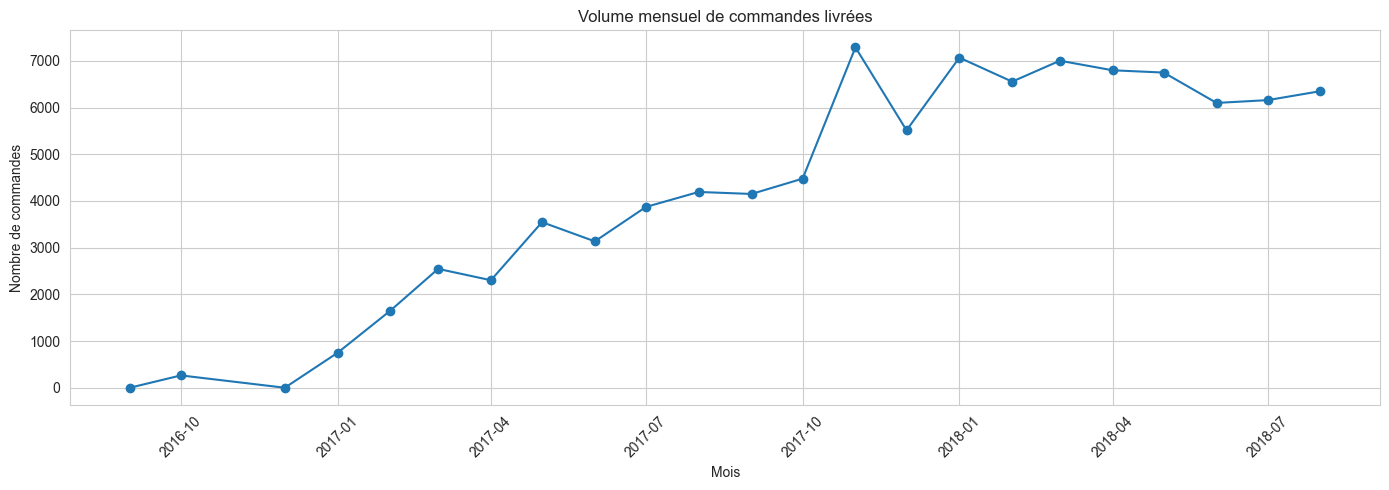

Période : 2016-09-01 00:00:00 → 2018-08-01 00:00:00


In [7]:
temporal = con.execute("""
    SELECT 
        DATE_TRUNC('month', order_purchase_timestamp) AS month,
        COUNT(*) AS n_orders,
        COUNT(DISTINCT customer_id) AS n_customers
    FROM orders
    WHERE order_status = 'delivered'
    GROUP BY 1
    ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(temporal['month'], temporal['n_orders'], marker='o')
ax.set_title("Volume mensuel de commandes livrées")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de commandes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Période : {temporal['month'].min()} → {temporal['month'].max()}")

## 8. Distribution de la fréquence d'achat

**Question critique pour le projet** : combien de clients sont mono-acheteurs 
vs multi-acheteurs ?

### Pourquoi c'est central
Cette distribution conditionne toute la stratégie de modélisation :
- Si **>90% des clients sont mono-acheteurs** → le "churn" devient en pratique 
  "probabilité de revenir une 2e fois". C'est le cas Olist.
- Si la base est plus équilibrée → on peut faire un modèle classique sur les 
  multi-acheteurs.

### Interprétation attendue
Sur Olist, on s'attend à voir ~97% de clients avec **1 seule commande**, et 
une queue très fine de multi-acheteurs. C'est un challenge réaliste : prédire 
la **réactivation**, pas juste le décrochage.


In [8]:
purchase_frequency = con.execute("""
    WITH customer_orders AS (
        SELECT 
            c.customer_unique_id,
            COUNT(DISTINCT o.order_id) AS n_orders
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
        GROUP BY 1
    )
    SELECT 
        n_orders,
        COUNT(*) AS n_customers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM customer_orders
    GROUP BY 1
    ORDER BY 1
""").df()

print(purchase_frequency.head(10))

   n_orders  n_customers    pct
0         1        90557  97.00
1         2         2573   2.76
2         3          181   0.19
3         4           28   0.03
4         5            9   0.01
5         6            5   0.01
6         7            3   0.00
7         9            1   0.00
8        15            1   0.00


## 9. Calibration de la fenêtre de churn (180 jours)

On analyse les **temps inter-achats** des clients multi-acheteurs pour 
**justifier empiriquement** le seuil de 180 jours retenu pour définir le churn.

### Méthode
On utilise la window function `LAG()` pour calculer, pour chaque commande, 
le temps écoulé depuis la commande précédente du même client.

### Ce qu'on cherche dans les statistiques descriptives
- **Médiane / 75e percentile** : si le 75e percentile est autour de 150-200 
  jours, alors un seuil de 180j est cohérent (= au-delà, c'est anormal)
- **95e percentile** : pour comprendre la queue de distribution

### Interprétation du graphique
- Si le pic de la distribution est clairement **avant** la barre rouge des 
  180j → le seuil capture bien un comportement anormal
- Si beaucoup de clients reviennent **après** 180j → il faudrait peut-être 
  élargir à 240j

Ce graphique est un excellent visuel pour ton README et ton dashboard Power BI 
("Pourquoi 180 jours ?").

Statistiques inter-achats (jours) :
count    3120.000000
mean       79.147436
std       107.295465
min         0.000000
25%         0.000000
50%        29.000000
75%       122.000000
90%       240.100000
95%       312.000000
max       609.000000
Name: days_between, dtype: float64


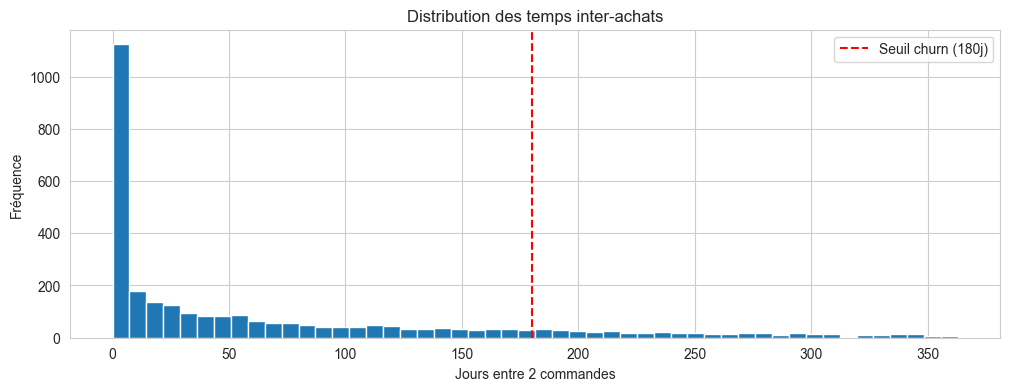

In [9]:
inter_purchase = con.execute("""
    WITH ordered_purchases AS (
        SELECT 
            c.customer_unique_id,
            o.order_purchase_timestamp,
            LAG(o.order_purchase_timestamp) OVER (
                PARTITION BY c.customer_unique_id 
                ORDER BY o.order_purchase_timestamp
            ) AS prev_purchase
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_status = 'delivered'
    )
    SELECT 
        DATE_DIFF('day', prev_purchase, order_purchase_timestamp) AS days_between
    FROM ordered_purchases
    WHERE prev_purchase IS NOT NULL
""").df()

print("Statistiques inter-achats (jours) :")
print(inter_purchase['days_between'].describe(percentiles=[.25, .5, .75, .9, .95]))

fig, ax = plt.subplots(figsize=(12, 4))
inter_purchase[inter_purchase['days_between'] < 365]['days_between'].hist(bins=50, ax=ax)
ax.axvline(180, color='red', linestyle='--', label='Seuil churn (180j)')
ax.set_xlabel("Jours entre 2 commandes")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution des temps inter-achats")
ax.legend()
plt.show()

## 🎯 Synthèse de l'étape 1

| Question | Réponse |
|----------|---------|
| Période couverte du dataset | 2016-09-01 → 2018-08-01 |
| Date de référence pour le churn (max purchase date) | 2018-08-01 |
| Nombre de clients uniques | 93 358 (`customer_unique_id`) sur 99 441 `customer_id` |
| % de clients mono-acheteurs | 97,00 % (90 557 clients sur 93 358) |
| 75e percentile des inter-purchase times | 122 jours |
| Le seuil de 180j est-il pertinent ? |  Oui — entre P75 (122j) et P90 (240j), il capture bien un comportement anormal sans être trop laxiste |

### Constats clés
- **Phase de démarrage bruitée** : septembre 2016 → décembre 2016 avec des volumes anecdotiques (< 1000 commandes/mois). À exclure de la fenêtre d'observation.
- **Régime stable atteint** à partir de novembre 2017 (~6 000-7 000 commandes/mois).
- **Pic Black Friday Brasil** visible en novembre 2017.
- **97 % de mono-acheteurs** : invalide l'approche RFM classique → choix de l'**Approche A (prédiction de réactivation)** pour l'étape 2.
- **Inter-purchase times très étalés** : médiane à 29j, P75 à 122j, P90 à 240j. Le seuil de 180j positionne la frontière churn entre P75 et P90, ce qui est méthodologiquement défendable.
- **Aucun problème de qualité de données** détecté (pas de doublons, pas de nulls critiques).
- **Piège technique identifié** : `customer_id` ≠ `customer_unique_id` → toutes les analyses client utilisent `customer_unique_id`.